### Import

In [95]:
#!pip install mlflow
import os
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
print('✓ Imports done')

✓ Imports done


In [81]:
%run utility_function.ipynb

### Config (only cell you need to edit day-to-day)

In [82]:
# ── Data paths ─────────────────────────────────────────────────────────────────
DATA_PATHS = {
    'home_team':   '../data/Train_Data/train_home_team_statistics_df.csv',
    'away_team':   '../data/Train_Data/train_away_team_statistics_df.csv',
    'home_player': '../data/Train_Data/train_home_player_statistics_df.csv',
    'away_player': '../data/Train_Data/train_away_player_statistics_df.csv',
    'scores':      '../data/Y_train.csv'
}

# ── Features (add/remove freely) ───────────────────────────────────────────────
TEAM_FEATURES = [
    'TEAM_SHOTS_ON_TARGET_5_last_match_sum',
    'TEAM_GOALS_5_last_match_sum',
    'TEAM_DANGEROUS_ATTACKS_5_last_match_sum',
    'TEAM_GAME_WON_5_last_match_sum',
    'TEAM_GAME_DRAW_5_last_match_sum',
    'TEAM_GAME_LOST_5_last_match_sum',
    'TEAM_SAVES_5_last_match_sum',
    # New features addded on 1March
    'TEAM_INJURIES_5_last_match_sum',
    'TEAM_REDCARDS_5_last_match_sum',
]

PLAYER_FEATURES = [
    'PLAYER_GOALS_5_last_match_average',
    'PLAYER_ASSISTS_5_last_match_average',
    'PLAYER_MINUTES_PLAYED_5_last_match_average',
    'PLAYER_STARTING_LINEUP_5_last_match_average',
    'PLAYER_GOALS_CONCEDED_5_last_match_average',
    'PLAYER_GOALS_season_sum',
    'PLAYER_YELLOWCARDS_5_last_match_sum',
    'PLAYER_GOALS_season_std',
    'PLAYER_PENALTIES_SCORED_season_sum',
    'PLAYER_REDCARDS_season_average',
]

# Give this experiment run a human-readable version tag so you can
# identify it in MLflow UI without decoding run IDs.
# Bump this every time you change TEAM_FEATURES or PLAYER_FEATURES.
FEATURE_VERSION = "v2"   # → change to "v2" when you add new features, etc.

# ── Active models (comment out to disable) ─────────────────────────────────────
ACTIVE_MODELS = [
    # 'LogisticRegression',
    # 'RandomForest',
    'XGBoost',
    # 'LightGBM',
    'NeuralNetwork',
]

# ── Active feature sets (comment out to disable) ───────────────────────────────
ACTIVE_FEATURE_SETS = [
    'Raw Only (Type 1)',
    'Raw + Diff (Type 1+2)',
    'Raw + Ratio (Type 1+3)',
    'All Features (Type 1+2+3)',
    'Engineered Only (Type 2+3)',
]

# ── Training settings ──────────────────────────────────────────────────────────
TEST_SIZE         = 0.2
N_CV_SPLITS       = 5
MODEL_SAVE_DIR    = '../saved_models/'
MLFLOW_EXPERIMENT = 'football_prediction'
# Class balance strategy: 'balanced', 'custom', or None
CLASS_WEIGHT_STRATEGY = 'balanced'

# Only used if CLASS_WEIGHT_STRATEGY = 'custom' — tune these weights
CUSTOM_CLASS_WEIGHTS = {
    0: 1.0,  # Away Win
    1: 3.0,  # Draw — boost this since it's hardest to predict
    2: 1.0,  # Home Win
}

# ── Competition Submission settings ──────────────────────────────────────────────────────────
CSV_SUBMISSION_PATH = '../data/submission_data'

print('✓ Config set')

✓ Config set


### Load Raw Data

In [83]:
raw = {key: pd.read_csv(path) for key, path in DATA_PATHS.items()}

for key, df in raw.items():
    print(f'  {key}: {df.shape}')

  home_team: (12303, 143)
  away_team: (12303, 143)
  home_player: (237079, 307)
  away_player: (236132, 307)
  scores: (12303, 4)


### Build Master DataFrame

In [84]:
# Encode target FIRST so label cols never leak into features
scores = raw['scores'].copy()
conditions = [scores['HOME_WINS'] == 1, scores['DRAW'] == 1, scores['AWAY_WINS'] == 1]
scores['target'] = np.select(conditions, [2, 1, 0], default=np.nan)

nan_count = scores['target'].isna().sum()
if nan_count > 0:
    print(f'⚠️  {nan_count} rows with no valid target — check Y_train.csv')

# Start from [ID, target] only — HOME_WINS / DRAW / AWAY_WINS never enter master_df
master_df = scores[['ID', 'target']].copy()

# Aggregate player rows to one row per match
home_player_agg = raw['home_player'].groupby('ID')[PLAYER_FEATURES].mean().reset_index()
away_player_agg = raw['away_player'].groupby('ID')[PLAYER_FEATURES].mean().reset_index()

# Helper: prefix columns and merge
def prefix_merge(base_df, source_df, prefix):
    prefixed = source_df.add_prefix(prefix).rename(columns={f'{prefix}ID': 'ID'})
    return base_df.merge(prefixed, on='ID', how='left')

master_df = prefix_merge(master_df, raw['home_team'][['ID'] + TEAM_FEATURES], 'HOME_')
master_df = prefix_merge(master_df, home_player_agg,                           'HOME_')
master_df = prefix_merge(master_df, raw['away_team'][['ID'] + TEAM_FEATURES], 'AWAY_')
master_df = prefix_merge(master_df, away_player_agg,                           'AWAY_')

print(f'✓ master_df: {master_df.shape[0]} rows, {master_df.shape[1]} columns')
master_df.head(3)

✓ master_df: 12303 rows, 40 columns


,ID,target,HOME_TEAM_SHOTS_ON_TARGET_5_last_match_sum,HOME_TEAM_GOALS_5_last_match_sum,HOME_TEAM_DANGEROUS_ATTACKS_5_last_match_sum,HOME_TEAM_GAME_WON_5_last_match_sum,HOME_TEAM_GAME_DRAW_5_last_match_sum,HOME_TEAM_GAME_LOST_5_last_match_sum,HOME_TEAM_SAVES_5_last_match_sum,HOME_TEAM_INJURIES_5_last_match_sum,...,AWAY_PLAYER_GOALS_5_last_match_average,AWAY_PLAYER_ASSISTS_5_last_match_average,AWAY_PLAYER_MINUTES_PLAYED_5_last_match_average,AWAY_PLAYER_STARTING_LINEUP_5_last_match_average,AWAY_PLAYER_GOALS_CONCEDED_5_last_match_average,AWAY_PLAYER_GOALS_season_sum,AWAY_PLAYER_YELLOWCARDS_5_last_match_sum,AWAY_PLAYER_GOALS_season_std,AWAY_PLAYER_PENALTIES_SCORED_season_sum,AWAY_PLAYER_REDCARDS_season_average
0,0,0.0,3.0,4.0,6.0,2.0,0.0,10.0,0.0,1.0,...,7.777778,3.611111,59.500000,60.833333,38.611111,8.555556,16.666667,16.941176,5.500000,5.277778
1,1,1.0,7.0,10.0,3.0,8.0,3.0,0.0,5.0,3.0,...,3.333333,2.222222,67.111111,69.722222,39.777778,3.000000,18.388889,7.555556,1.833333,1.666667
2,2,0.0,4.0,3.0,4.0,4.0,0.0,7.0,3.0,2.0,...,3.521739,7.173913,58.739130,61.739130,43.391304,4.652174,14.782609,14.954545,1.304348,11.260870


### Engineer DIFF & RATIO Features

In [85]:
for col in TEAM_FEATURES + PLAYER_FEATURES:
    h, a = f'HOME_{col}', f'AWAY_{col}'
    if h in master_df.columns and a in master_df.columns:
        master_df[f'DIFF_{col}']  = master_df[h] - master_df[a]
        master_df[f'RATIO_{col}'] = (master_df[h] + 1) / (master_df[a] + 1)
    else:
        print(f'  ⚠️  Skipping {col} — HOME/AWAY columns not found')

print(f'✓ master_df after feature engineering: {master_df.shape[1]} columns')

✓ master_df after feature engineering: 78 columns


### Define Feature Groups & Model Configs

In [86]:
# ── Feature groups ─────────────────────────────────────────────────────────────
non_features   = {'ID', 'target'}
home_away_cols = [c for c in master_df.columns if ('HOME_' in c or 'AWAY_' in c) and c not in non_features]
diff_cols      = [c for c in master_df.columns if c.startswith('DIFF_')]
ratio_cols     = [c for c in master_df.columns if c.startswith('RATIO_')]

ALL_FEATURE_SETS = {
    'Raw Only (Type 1)':          home_away_cols,
    #'Raw + Diff (Type 1+2)':      home_away_cols + diff_cols,
    'Raw + Ratio (Type 1+3)':     home_away_cols + ratio_cols,
    #'All Features (Type 1+2+3)':  home_away_cols + diff_cols + ratio_cols,
    #'Engineered Only (Type 2+3)': diff_cols + ratio_cols,
}

feature_experiments = {k: v for k, v in ALL_FEATURE_SETS.items() if k in ACTIVE_FEATURE_SETS}
print(f'✓ Feature sets: {list(feature_experiments.keys())}')

# ── Model registry ─────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced weights from training data
classes     = np.array([0, 1, 2])
cw_balanced = compute_class_weight('balanced', classes=classes, y=master_df['target'].astype(int))
cw_dict     = dict(zip(classes, cw_balanced))
print(f'Computed class weights: {cw_dict}')
# Expected output roughly: {0: 1.1, 1: 2.8, 2: 0.8} — Draw gets highest weight

# Pick which weight dict to use based on config
if CLASS_WEIGHT_STRATEGY == 'balanced':
    weight_dict = cw_dict
elif CLASS_WEIGHT_STRATEGY == 'custom':
    weight_dict = CUSTOM_CLASS_WEIGHTS
else:
    weight_dict = None

MODEL_REGISTRY = {
    'LogisticRegression': {
        'model': LogisticRegression(
            multi_class='multinomial', max_iter=2000, solver='lbfgs',
            class_weight=weight_dict  # ← added
        ),
        'params': {
            'clf__C':       [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
        },
    },
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight=weight_dict  # ← added
        ),
        'params': {
            'clf__n_estimators':     [100, 200],
            'clf__max_depth':        [5, 10, None],
            'clf__min_samples_leaf': [4, 10],
        },
    },
    'XGBoost': {
        'model': XGBClassifier(
            use_label_encoder=False, eval_metric='mlogloss', random_state=42,
            # XGBoost uses sample_weight, not class_weight — handled in Cell 7
        ),
        'params': {
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__n_estimators':  [200, 500, 1000], # Increased for better convergence
            'clf__max_depth':     [3,4,5,6],
            'clf__subsample': [0.8], # "Dropout" for trees
            'clf__colsample_bytree': [0.7, 0.8, 1.0],
            'clf__min_child_weight': [1, 3, 5],
        },
    },
    'LightGBM': {
        'model': LGBMClassifier(
            random_state=42, verbose=-1,
            class_weight=weight_dict  # ← added
        ),
        'params': {
            'clf__learning_rate': [0.01, 0.1],
            'clf__n_estimators':  [100, 200],
            'clf__num_leaves':    [31, 50],
        },
    },
    'NeuralNetwork': {
        'model': MLPClassifier(max_iter=1000, random_state=42, early_stopping= True),
        # MLPClassifier has no class_weight — we handle via resampling below
        'params': {
            'clf__hidden_layer_sizes': [(32, 16), (16,)],
            'clf__alpha':              [0.1, 1.0, 10.0],
            'clf__activation':         ['relu'],
        },
    },
}

model_configs = {k: MODEL_REGISTRY[k] for k in ACTIVE_MODELS if k in MODEL_REGISTRY}
print(f'✓ Models: {list(model_configs.keys())}')

✓ Feature sets: ['Raw Only (Type 1)', 'Raw + Ratio (Type 1+3)']
Computed class weights: {np.int64(0): np.float64(1.0904014889657005), np.int64(1): np.float64(1.2871939736346516), np.int64(2): np.float64(0.7656833457804332)}
✓ Models: ['XGBoost', 'NeuralNetwork']


### Run experiments

In [87]:
mlflow.set_tracking_uri("file:///C:/mlflow_tracking")
mlflow.set_experiment(MLFLOW_EXPERIMENT)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

results = []
total   = len(feature_experiments) * len(model_configs)
done    = 0

for feat_name, feat_cols in feature_experiments.items():
    print(f'\n>>> Feature Set: {feat_name}  ({len(feat_cols)} features)')

    X = master_df[feat_cols]
    y = master_df['target'].astype(int)  # XGBoost requires int labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=42
    )

    for model_name, config in model_configs.items():
        done += 1
        print(f'  [{done}/{total}] {model_name}...', end=' ', flush=True)

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  StandardScaler()),
            ('clf',     config['model']),
        ])

        cv = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=42)
        grid_search = GridSearchCV(
            pipeline, config['params'],
            cv=cv, scoring='accuracy',
            n_jobs=-1, return_train_score=True,
        )
        # XGBoost needs sample_weight passed to fit(), not the model constructor
        if model_name == 'XGBoost' and weight_dict is not None:
            sample_weights = np.array([weight_dict[label] for label in y_train])
            grid_search.fit(X_train, y_train, clf__sample_weight=sample_weights)
        else:
            grid_search.fit(X_train, y_train)

        best_idx   = grid_search.best_index_
        train_acc  = grid_search.cv_results_['mean_train_score'][best_idx]
        val_acc    = grid_search.best_score_
        test_acc   = accuracy_score(y_test, grid_search.predict(X_test))
        best_model = grid_search.best_estimator_

        # Save model — filename includes feature set so files don't overwrite each other
        safe_feat  = feat_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
        model_path = save_model_bundle(
            pipeline        = best_model,
            model_name      = model_name,
            feat_name       = feat_name,
            feat_cols       = feat_cols,
            team_features   = TEAM_FEATURES,
            player_features = PLAYER_FEATURES,
            feature_version = FEATURE_VERSION,
            model_save_dir  = MODEL_SAVE_DIR,
            metrics         = {"train": train_acc, "val": val_acc, "test": test_acc},
        )
        print(f"  Saved → {model_path}")

        # MLflow — run name includes both model AND feature set (bug fix from original)
        with mlflow.start_run(run_name=f'{model_name}_{feat_name}_{FEATURE_VERSION}'):
            mlflow.set_tag("feature_version",   FEATURE_VERSION)
            mlflow.set_tag("feature_set_name",  feat_name)
            mlflow.set_tag("n_features",        len(feat_cols))
            mlflow.log_param("team_features",   str(TEAM_FEATURES))
            mlflow.log_param("player_features", str(PLAYER_FEATURES))
            mlflow.log_param("feat_cols",       str(feat_cols))   # exact columns fed to model
            #-------------
            mlflow.log_param('model', model_name)
            mlflow.log_param('class_weight_strategy',  CLASS_WEIGHT_STRATEGY)
            mlflow.log_params({k: str(v) for k, v in grid_search.best_params_.items()})
            mlflow.log_metric('train_accuracy', train_acc)
            mlflow.log_metric('val_accuracy',   val_acc)
            mlflow.log_metric('test_accuracy',  test_acc)
            mlflow.log_metric('overfit_gap',    train_acc - val_acc)
            mlflow.sklearn.log_model(best_model, artifact_path='model')

        results.append({
            'Feature Set':             feat_name,
            'Model':                   model_name,
            'Best Params':             grid_search.best_params_,
            'Train Accuracy':          round(train_acc, 4),
            'Val Accuracy (CV)':       round(val_acc,   4),
            'Test Accuracy':           round(test_acc,  4),
            'Overfit Gap (Train-Val)': round(train_acc - val_acc, 4),
        })

        print(f'train={train_acc:.3f} | val={val_acc:.3f} | test={test_acc:.3f} | gap={train_acc - val_acc:.3f}')

print('\n✓ All experiments done')


>>> Feature Set: Raw Only (Type 1)  (38 features)
  [1/4] XGBoost... 

2026/03/01 16:08:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Saved → ../saved_models/XGBoost_Raw_Only_Type_1_v2.pkl


2026/03/01 16:08:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


train=0.924 | val=0.455 | test=0.449 | gap=0.469
  [2/4] NeuralNetwork... 

...

train=0.503 | val=0.455 | test=0.460 | gap=0.049
  [4/4] NeuralNetwork... 

2026/03/01 16:25:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Saved → ../saved_models/NeuralNetwork_Raw__Ratio_Type_13_v2.pkl


2026/03/01 16:25:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


train=0.487 | val=0.485 | test=0.485 | gap=0.002

✓ All experiments done


### Results

In [89]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)

display(results_df[[
    'Feature Set', 'Model',
    'Train Accuracy', 'Val Accuracy (CV)',
    'Test Accuracy', 'Overfit Gap (Train-Val)'
]].reset_index(drop=True))

print('\nPredicted class distributions (want ~30% Away, ~26% Draw, ~44% Home):')

# Original v1 feature lists — DO NOT update these when you add new features
# These are the fallbacks for bare pkls saved before the bundle format
TEAM_FEATURES_V1 = [
    'TEAM_SHOTS_ON_TARGET_5_last_match_sum',
    'TEAM_GOALS_5_last_match_sum',
    'TEAM_DANGEROUS_ATTACKS_5_last_match_sum',
    'TEAM_GAME_WON_5_last_match_sum',
    'TEAM_GAME_DRAW_5_last_match_sum',
    'TEAM_GAME_LOST_5_last_match_sum',
    'TEAM_SAVES_5_last_match_sum',
]

PLAYER_FEATURES_V1 = [
    'PLAYER_GOALS_5_last_match_average',
    'PLAYER_ASSISTS_5_last_match_average',
    'PLAYER_MINUTES_PLAYED_5_last_match_average',
    'PLAYER_STARTING_LINEUP_5_last_match_average',
    'PLAYER_GOALS_CONCEDED_5_last_match_average',
    'PLAYER_GOALS_season_sum',
    'PLAYER_YELLOWCARDS_5_last_match_sum',
    'PLAYER_GOALS_season_std',
    'PLAYER_PENALTIES_SCORED_season_sum',
    'PLAYER_REDCARDS_season_average',
]

for row in results:
    safe_feat      = row['Feature Set'].replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    # version_suffix = f"_{FEATURE_VERSION}" if FEATURE_VERSION else ""
    model_path     = os.path.join(MODEL_SAVE_DIR, f"{row['Model']}_{safe_feat}_{FEATURE_VERSION}.pkl")

    pipeline, feat_cols, team_features, player_features = load_model_bundle(
        model_path,
        fallback_feat_cols = feature_experiments[row['Feature Set']],
        fallback_team      = TEAM_FEATURES_V1,
        fallback_player    = PLAYER_FEATURES_V1,
    )

    # Rebuild master_df from the feature lists inside the bundle
    home_player_agg = raw["home_player"].groupby("ID")[player_features].mean().reset_index()
    away_player_agg = raw["away_player"].groupby("ID")[player_features].mean().reset_index()

    master_bundle = scores[["ID", "target"]].copy()
    master_bundle = prefix_merge(master_bundle, raw["home_team"][["ID"] + team_features], "HOME_")
    master_bundle = prefix_merge(master_bundle, home_player_agg,                          "HOME_")
    master_bundle = prefix_merge(master_bundle, raw["away_team"][["ID"] + team_features], "AWAY_")
    master_bundle = prefix_merge(master_bundle, away_player_agg,                          "AWAY_")

    for col in team_features + player_features:
        h, a = f"HOME_{col}", f"AWAY_{col}"
        if h in master_bundle.columns and a in master_bundle.columns:
            master_bundle[f"DIFF_{col}"]  = master_bundle[h] - master_bundle[a]
            master_bundle[f"RATIO_{col}"] = (master_bundle[h] + 1) / (master_bundle[a] + 1)

    missing = [c for c in feat_cols if c not in master_bundle.columns]
    if missing:
        print(f"  ⚠️  {row['Model']} | {row['Feature Set']} — {len(missing)} missing columns: {missing}")
        continue  # skip this model rather than crashing

    _, X_test_bundle, _, _ = train_test_split(
        master_bundle[feat_cols], master_bundle["target"].astype(int),
        test_size=TEST_SIZE, stratify=master_bundle["target"].astype(int), random_state=42
    )

    predictions = pipeline.predict(X_test_bundle)
    away = (predictions == 0).mean() * 100
    draw = (predictions == 1).mean() * 100
    home = (predictions == 2).mean() * 100
    print(f"  {row['Model']:20s} | {row['Feature Set']:30s} | Away={away:.1f}% Draw={draw:.1f}% Home={home:.1f}%")

,Feature Set,Model,Train Accuracy,Val Accuracy (CV),Test Accuracy,Overfit Gap (Train-Val)
0,Raw + Ratio (Type 1+3),NeuralNetwork,0.4870,0.4848,0.4848,0.0023
1,Raw Only (Type 1),NeuralNetwork,0.4867,0.4831,0.4823,0.0036
2,Raw + Ratio (Type 1+3),XGBoost,0.5034,0.4546,0.4600,0.0488
3,Raw Only (Type 1),XGBoost,0.9242,0.4555,0.4494,0.4687



Predicted class distributions (want ~30% Away, ~26% Draw, ~44% Home):
  [bundle] XGBoost  v2  | 38 features | metrics={'train': np.float64(0.9241515413552864), 'val': np.float64(0.4554960113466041), 'test': 0.44941080861438437}
  XGBoost              | Raw Only (Type 1)              | Away=34.9% Draw=21.2% Home=43.9%
  [bundle] NeuralNetwork  v2  | 38 features | metrics={'train': np.float64(0.48668959908731446), 'val': np.float64(0.48313281679033143), 'test': 0.48232425843153187}
  NeuralNetwork        | Raw Only (Type 1)              | Away=29.2% Draw=0.0% Home=70.8%
  [bundle] XGBoost  v2  | 57 features | metrics={'train': np.float64(0.503403664879221), 'val': np.float64(0.4545822030084191), 'test': 0.4599756196668021}
  XGBoost              | Raw + Ratio (Type 1+3)         | Away=38.8% Draw=21.2% Home=40.1%
  [bundle] NeuralNetwork  v2  | 57 features | metrics={'train': np.float64(0.48701992234417596), 'val': np.float64(0.4847589362765136), 'test': 0.48476229175132063}
  NeuralNetw

In [91]:
for row in results:
    safe_feat      = row['Feature Set'].replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    version_suffix = f"_{FEATURE_VERSION}" 
    model_path     = os.path.join(MODEL_SAVE_DIR, f"{row['Model']}_{safe_feat}{version_suffix}.pkl")
    print(model_path)

../saved_models/XGBoost_Raw_Only_Type_1_v2.pkl
../saved_models/NeuralNetwork_Raw_Only_Type_1_v2.pkl
../saved_models/XGBoost_Raw__Ratio_Type_13_v2.pkl
../saved_models/NeuralNetwork_Raw__Ratio_Type_13_v2.pkl


PER-MODEL CONFUSION MATRICES
  [bundle] XGBoost    | 38 features | metrics={'train': np.float64(0.8873705095054035), 'val': np.float64(0.44350543175314944), 'test': 0.45306785859406745}


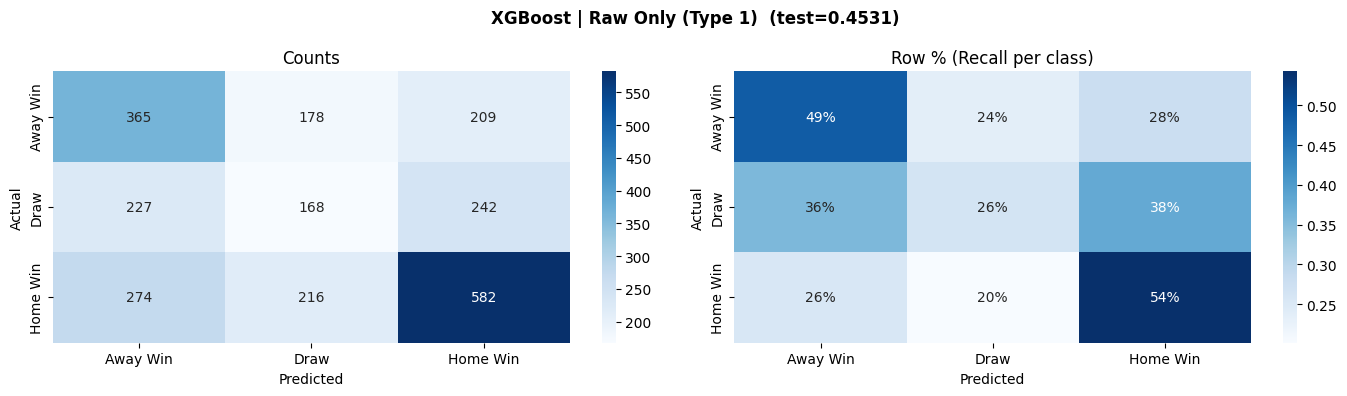

              precision    recall  f1-score   support

    Away Win      0.421     0.485     0.451       752
        Draw      0.299     0.264     0.280       637
    Home Win      0.563     0.543     0.553      1072

    accuracy                          0.453      2461
   macro avg      0.428     0.431     0.428      2461
weighted avg      0.452     0.453     0.451      2461

  Per-class accuracy:  Away=48.5%  Draw=26.4%  Home=54.3%
------------------------------------------------------------
  [bundle] NeuralNetwork    | 38 features | metrics={'train': np.float64(0.7606681745816177), 'val': np.float64(0.402355772605466), 'test': 0.3986184477854531}


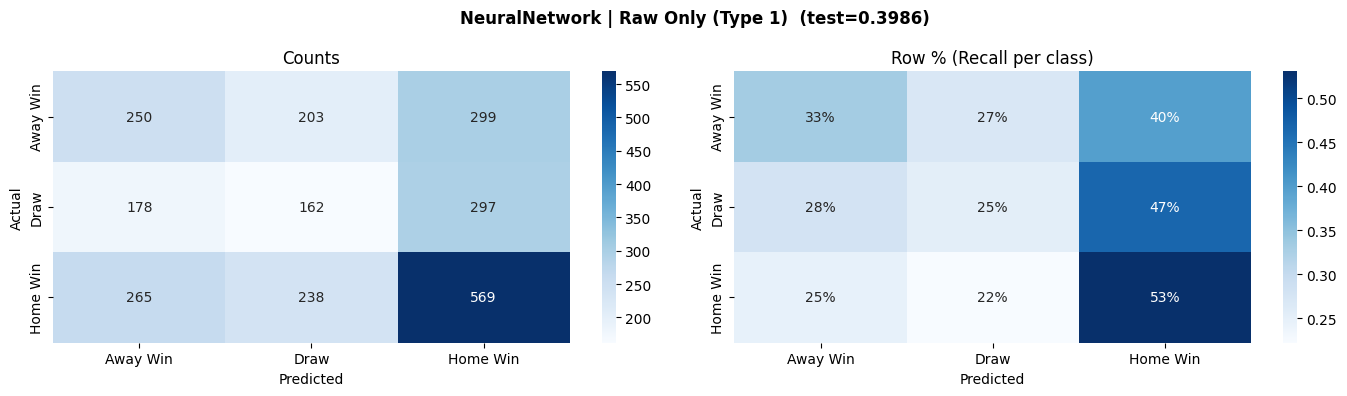

              precision    recall  f1-score   support

    Away Win      0.361     0.332     0.346       752
        Draw      0.269     0.254     0.261       637
    Home Win      0.488     0.531     0.509      1072

    accuracy                          0.399      2461
   macro avg      0.373     0.373     0.372      2461
weighted avg      0.393     0.399     0.395      2461

  Per-class accuracy:  Away=33.2%  Draw=25.4%  Home=53.1%
------------------------------------------------------------


KeyError: 'Raw + Diff (Type 1+2)'

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 60)
print('PER-MODEL CONFUSION MATRICES')
print('=' * 60)

LABEL_NAMES = ['Away Win', 'Draw', 'Home Win']

for row in results:
    safe_feat      = row['Feature Set'].replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    model_path     = os.path.join(MODEL_SAVE_DIR, f"{row['Model']}_{safe_feat}_{FEATURE_VERSION}.pkl")

    pipeline, feat_cols, team_features, player_features = load_model_bundle(
        model_path,
        fallback_feat_cols = feature_experiments[row['Feature Set']],
        fallback_team      = TEAM_FEATURES_V1,
        fallback_player    = PLAYER_FEATURES_V1,
    )

    # Rebuild master and split
    home_player_agg = raw["home_player"].groupby("ID")[player_features].mean().reset_index()
    away_player_agg = raw["away_player"].groupby("ID")[player_features].mean().reset_index()

    master_bundle = scores[["ID", "target"]].copy()
    master_bundle = prefix_merge(master_bundle, raw["home_team"][["ID"] + team_features], "HOME_")
    master_bundle = prefix_merge(master_bundle, home_player_agg,                          "HOME_")
    master_bundle = prefix_merge(master_bundle, raw["away_team"][["ID"] + team_features], "AWAY_")
    master_bundle = prefix_merge(master_bundle, away_player_agg,                          "AWAY_")

    for col in team_features + player_features:
        h, a = f"HOME_{col}", f"AWAY_{col}"
        if h in master_bundle.columns and a in master_bundle.columns:
            master_bundle[f"DIFF_{col}"]  = master_bundle[h] - master_bundle[a]
            master_bundle[f"RATIO_{col}"] = (master_bundle[h] + 1) / (master_bundle[a] + 1)

    _, X_test_bundle, _, y_test_bundle = train_test_split(
        master_bundle[feat_cols], master_bundle["target"].astype(int),
        test_size=TEST_SIZE, stratify=master_bundle["target"].astype(int), random_state=42
    )

    predictions = pipeline.predict(X_test_bundle)

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_test_bundle, predictions, labels=[0, 1, 2])
    
    # Per-class accuracy from the confusion matrix
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{row['Model']} | {row['Feature Set']}  "
                 f"(test={row['Test Accuracy']:.4f})", fontsize=12, fontweight='bold')

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
    axes[0].set_title('Counts')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Normalised (row %) — shows recall per class clearly
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
    axes[1].set_title('Row % (Recall per class)')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    # ── Classification report ─────────────────────────────────────────────────
    print(classification_report(y_test_bundle, predictions,
                                target_names=LABEL_NAMES, digits=3))
    print(f"  Per-class accuracy:  "
          f"Away={per_class_acc[0]:.1%}  "
          f"Draw={per_class_acc[1]:.1%}  "
          f"Home={per_class_acc[2]:.1%}")
    print('-' * 60)

### Build Test Master DataFrame

In [93]:
# ── Load test data ─────────────────────────────────────────────────────────────
test_home_team   = pd.read_csv('../data/Test_Data/test_home_team_statistics_df.csv')
test_away_team   = pd.read_csv('../data/Test_Data/test_away_team_statistics_df.csv')
test_home_player = pd.read_csv('../data/Test_Data/test_home_player_statistics_df.csv')
test_away_player = pd.read_csv('../data/Test_Data/test_away_player_statistics_df.csv')
test_scores      = pd.read_csv('../data/Y_test_random.csv')

# ── Aggregate player rows ──────────────────────────────────────────────────────
test_home_player_agg = test_home_player.groupby('ID')[PLAYER_FEATURES].mean().reset_index()
test_away_player_agg = test_away_player.groupby('ID')[PLAYER_FEATURES].mean().reset_index()

# ── Merge (same logic as training, reusing prefix_merge from Cell 4) ───────────
test_master = test_scores[['ID']].copy()  # No target — this is test data

test_master = prefix_merge(test_master, test_home_team[['ID'] + TEAM_FEATURES], 'HOME_')
test_master = prefix_merge(test_master, test_home_player_agg,                   'HOME_')
test_master = prefix_merge(test_master, test_away_team[['ID'] + TEAM_FEATURES], 'AWAY_')
test_master = prefix_merge(test_master, test_away_player_agg,                   'AWAY_')

# ── Engineer DIFF & RATIO features (same logic as Cell 5) ─────────────────────
for col in TEAM_FEATURES + PLAYER_FEATURES:
    h, a = f'HOME_{col}', f'AWAY_{col}'
    if h in test_master.columns and a in test_master.columns:
        test_master[f'DIFF_{col}']  = test_master[h] - test_master[a]
        test_master[f'RATIO_{col}'] = (test_master[h] + 1) / (test_master[a] + 1)

print(f'✓ test_master: {test_master.shape[0]} rows, {test_master.shape[1]} columns')
test_master.head(3)

✓ test_master: 25368 rows, 77 columns


,ID,HOME_TEAM_SHOTS_ON_TARGET_5_last_match_sum,HOME_TEAM_GOALS_5_last_match_sum,HOME_TEAM_DANGEROUS_ATTACKS_5_last_match_sum,HOME_TEAM_GAME_WON_5_last_match_sum,HOME_TEAM_GAME_DRAW_5_last_match_sum,HOME_TEAM_GAME_LOST_5_last_match_sum,HOME_TEAM_SAVES_5_last_match_sum,HOME_TEAM_INJURIES_5_last_match_sum,HOME_TEAM_REDCARDS_5_last_match_sum,...,DIFF_PLAYER_GOALS_season_sum,RATIO_PLAYER_GOALS_season_sum,DIFF_PLAYER_YELLOWCARDS_5_last_match_sum,RATIO_PLAYER_YELLOWCARDS_5_last_match_sum,DIFF_PLAYER_GOALS_season_std,RATIO_PLAYER_GOALS_season_std,DIFF_PLAYER_PENALTIES_SCORED_season_sum,RATIO_PLAYER_PENALTIES_SCORED_season_sum,DIFF_PLAYER_REDCARDS_season_average,RATIO_PLAYER_REDCARDS_season_average
0,12303,0.0,2.0,5.0,0.0,3.0,10.0,6.0,3.0,10.0,...,-6.762626,0.319959,-7.055556,0.693976,-9.595238,0.406480,-1.833333,0.352941,-0.777778,0.762712
1,12304,2.0,4.0,6.0,5.0,5.0,3.0,6.0,2.0,10.0,...,-3.444444,0.614907,0.000000,1.000000,-3.006536,0.868646,-5.555556,0.275362,-1.944444,0.339623
2,12305,4.0,2.0,10.0,7.0,5.0,2.0,4.0,3.0,5.0,...,6.307190,2.207760,-1.127451,0.918498,7.493464,1.486940,0.130719,1.040568,-0.944444,0.514286


### Generate Submission

In [109]:
# ── Pick your best model ───────────────────────────────────────────────────────
BEST_MODEL_NAME  = 'NeuralNetwork'
BEST_FEATURE_SET = 'Raw + Ratio (Type 1+3)'
FEATURE_VERSION  = 'v2'

# ── Load via bundle (handles both bare and bundle format) ──────────────────────
safe_feat      = BEST_FEATURE_SET.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
model_path     = os.path.join(MODEL_SAVE_DIR, f'{BEST_MODEL_NAME}_{safe_feat}_{FEATURE_VERSION}.pkl')

best_pipeline, feat_cols, team_features, player_features = load_model_bundle(
    model_path,
    fallback_feat_cols = feature_experiments[BEST_FEATURE_SET],
    fallback_team      = TEAM_FEATURES_V1,    # frozen v1 lists for bare pkls
    fallback_player    = PLAYER_FEATURES_V1,
)
print(f'✓ Loaded model: {model_path}')
print(f'  Features: {len(feat_cols)} columns')

# ── Rebuild test_master using the bundle's feature lists ──────────────────────
# (same fix as the results loop — guarantees column alignment with what the model saw)
test_home_player_agg = test_home_player.groupby('ID')[player_features].mean().reset_index()
test_away_player_agg = test_away_player.groupby('ID')[player_features].mean().reset_index()

test_master = test_scores[['ID']].copy()
test_master = prefix_merge(test_master, test_home_team[['ID'] + TEAM_FEATURES], 'HOME_')
test_master = prefix_merge(test_master, test_home_player_agg,                   'HOME_')
test_master = prefix_merge(test_master, test_away_team[['ID'] + TEAM_FEATURES], 'AWAY_')
test_master = prefix_merge(test_master, test_away_player_agg,                   'AWAY_')

for col in TEAM_FEATURES + PLAYER_FEATURES:
    h, a = f'HOME_{col}', f'AWAY_{col}'
    if h in test_master.columns and a in test_master.columns:
        test_master[f'DIFF_{col}']  = test_master[h] - test_master[a]
        test_master[f'RATIO_{col}'] = (test_master[h] + 1) / (test_master[a] + 1)

# ── Validate features ──────────────────────────────────────────────────────────
missing = [c for c in feat_cols if c not in test_master.columns]
if missing:
    print(f'⚠️  {len(missing)} feature columns missing from test data: {missing}')
else:
    print(f'✓ All {len(feat_cols)} feature columns present')

# ── Predict ───────────────────────────────────────────────────────────────────
predictions = best_pipeline.predict(test_master[feat_cols])

# ── Build submission ──────────────────────────────────────────────────────────
submission = pd.DataFrame({
    'ID':        test_master['ID'],
    'HOME_WINS': (predictions == 2).astype(int),
    'DRAW':      (predictions == 1).astype(int),
    'AWAY_WINS': (predictions == 0).astype(int),
})

assert submission.isnull().sum().sum() == 0, '⚠️  Submission contains NaNs!'
assert (submission[['AWAY_WINS', 'DRAW', 'HOME_WINS']].sum(axis=1) == 1).all(), \
    '⚠️  Each row must have exactly one winning class!'

# ── Save ──────────────────────────────────────────────────────────────────────
CSV_SUBMISSION_PATH = Path("submissions")
CSV_SUBMISSION_PATH.mkdir(exist_ok=True)

submission_path = CSV_SUBMISSION_PATH / f"submission_{BEST_MODEL_NAME}_{FEATURE_VERSION}.csv"
submission.to_csv(submission_path, index=False)

print(f'\n✓ Submission saved → {submission_path}')
print(f'  Rows: {len(submission)}')
print(f'\nClass distribution:')
print(f"  Away Wins : {submission['AWAY_WINS'].sum()} ({submission['AWAY_WINS'].mean()*100:.1f}%)")
print(f"  Draw      : {submission['DRAW'].sum()} ({submission['DRAW'].mean()*100:.1f}%)")
print(f"  Home Wins : {submission['HOME_WINS'].sum()} ({submission['HOME_WINS'].mean()*100:.1f}%)")

submission.head()

  [bundle] NeuralNetwork  v2  | 57 features | metrics={'train': np.float64(0.48701992234417596), 'val': np.float64(0.4847589362765136), 'test': 0.48476229175132063}
✓ Loaded model: ../saved_models/NeuralNetwork_Raw__Ratio_Type_13_v2.pkl
  Features: 57 columns
✓ All 57 feature columns present

✓ Submission saved → submissions\submission_NeuralNetwork_v2.csv
  Rows: 25368

Class distribution:
  Away Wins : 7118 (28.1%)
  Draw      : 0 (0.0%)
  Home Wins : 18250 (71.9%)


,ID,HOME_WINS,DRAW,AWAY_WINS
0,12303,1,0,0
1,12304,0,0,1
2,12305,1,0,0
3,12306,1,0,0
4,12307,1,0,0


In [108]:
test_file = Path(CSV_SUBMISSION_PATH) / "test.csv"
pd.DataFrame({"a":[1]}).to_csv(test_file, index=False)
print("Saved test file")

Saved test file


In [59]:
import inspect
print(inspect.getsource(prefix_merge))

def prefix_merge(base_df, source_df, prefix):
    prefixed = source_df.add_prefix(prefix).rename(columns={f'{prefix}ID': 'ID'})
    return base_df.merge(prefixed, on='ID', how='left')



In [60]:
del test_master  # force rebuild — prevent stale v1 test_master from persisting